<a href="https://colab.research.google.com/github/KaatarinaGalic/RacunalniVid/blob/main/RacunalniVidProjekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
!ls /content/drive/MyDrive


 brent_data.csv		 VOC2012_test
 Classroom		 VOC2012_test.zip
'Colab Notebooks'	 VOC_test_imagees
 data.csv		 wti_data.csv
 PZI.pdf		 yolo_dataset
 Untitled0.ipynb	 YOLO_VOC_Project
'Vizija PZI2.pdf'	'Zavrsni_rad-Katarina Galić(14469).docx'
'vjezba_racunalni vid'


In [8]:
!ls /content/drive/MyDrive/YOLO_VOC_Project


best.pt  train


In [4]:
!unzip /content/drive/MyDrive/VOC2012_test.zip -d /content/drive/MyDrive/


Izlaz streaminga skraćen je na ovoliko posljednjih redaka: 5000.
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001472.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001474.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001477.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001478.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001481.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001482.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001484.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001485.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001486.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001487.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001488.jpg  
  inflating: /content/drive/MyDrive/VOC2012_test/JPEGImages/2011_001490.jpg  

In [9]:
!ls  /content/drive/MyDrive/VOC2012_test


Annotations  ImageSets	JPEGImages


In [10]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.2 MB/s eta 0:00:00


In [13]:
import os

VOC_PATH = "/content/drive/MyDrive/VOC2012_test"
IMG_PATH = os.path.join(VOC_PATH, "JPEGImages")
ANN_PATH = os.path.join(VOC_PATH, "Annotations")
SET_PATH = os.path.join(VOC_PATH, "ImageSets/Main")


In [14]:
BASE_DIR = "/content/drive/MyDrive/yolo_dataset"

for split in ["train", "val"]:
    os.makedirs(f"{BASE_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE_DIR}/labels/{split}", exist_ok=True)


In [15]:
classes = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]


In [16]:
import xml.etree.ElementTree as ET
import shutil

def convert_voc_to_yolo(xml_file, img_file, label_file, img_dest):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    with open(label_file, "w") as f:
        for obj in root.findall("object"):
            cls = obj.find("name").text
            if cls not in classes:
                continue

            cls_id = classes.index(cls)
            bnd = obj.find("bndbox")

            xmin = int(bnd.find("xmin").text)
            ymin = int(bnd.find("ymin").text)
            xmax = int(bnd.find("xmax").text)
            ymax = int(bnd.find("ymax").text)

            x = ((xmin + xmax) / 2) / w
            y = ((ymin + ymax) / 2) / h
            bw = (xmax - xmin) / w
            bh = (ymax - ymin) / h

            f.write(f"{cls_id} {x} {y} {bw} {bh}\n")

    shutil.copy(img_file, img_dest)


In [17]:
import random
import os

all_images = [f.replace(".jpg", "") for f in os.listdir(IMG_PATH) if f.endswith(".jpg")]

print("Ukupno slika:", len(all_images))


Ukupno slika: 16135


In [18]:
random.shuffle(all_images)

train_files = all_images[:1500]
val_files = all_images[1500:1800]

print("Train:", len(train_files))
print("Val:", len(val_files))


Train: 1500
Val: 300


In [19]:
def process_files(files, split):
    for name in files:
        img_src = f"{IMG_PATH}/{name}.jpg"
        xml_src = f"{ANN_PATH}/{name}.xml"

        # preskoči ako fali XML (rijetko, ali sigurno)
        if not os.path.exists(xml_src):
            continue

        img_dest = f"{BASE_DIR}/images/{split}/{name}.jpg"
        label_dest = f"{BASE_DIR}/labels/{split}/{name}.txt"

        convert_voc_to_yolo(xml_src, img_src, label_dest, img_dest)

process_files(train_files, "train")
process_files(val_files, "val")


In [21]:
!ls /content/drive/MyDrive/yolo_dataset/images/train | head
!ls /content/drive/MyDrive/yolo_dataset/labels/train | head

2008_000438.jpg
2008_000720.jpg
2008_000946.jpg
2008_001033.jpg
2008_001273.jpg
2008_001634.jpg
2008_001748.jpg
2008_001754.jpg
2008_001778.jpg
2008_001840.jpg
2008_000438.txt
2008_000720.txt
2008_000946.txt
2008_001033.txt
2008_001273.txt
2008_001634.txt
2008_001748.txt
2008_001754.txt
2008_001778.txt
2008_001840.txt


In [22]:
%%writefile /content/voc_drive.yaml
path: /content/drive/MyDrive/yolo_dataset
train: images/train
val: images/val

names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor

Writing /content/voc_drive.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/voc.yaml",
    epochs=20,
    imgsz=640,
    batch=16
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/voc.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7185153860>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p /content/drive/MyDrive/YOLO_VOC_Project


In [ ]:
!cp /content/runs/detect/train/weights/best.pt /content/drive/MyDrive/YOLO_VOC_Project/


In [ ]:
!cp -r /content/runs/detect/train /content/drive/MyDrive/YOLO_VOC_Project/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_VOC_Project/best.pt")

results = model(
    "/content/drive/MyDrive/VOC_test_imagees",
    conf=0.6,
    save=True
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/5 /content/drive/MyDrive/VOC_test_imagees/test1.jpg: 480x640 1 person, 63.9ms
image 2/5 /content/drive/MyDrive/VOC_test_imagees/test2.jpg: 512x640 1 person, 39.8ms
image 3/5 /content/drive/MyDrive/VOC_test_imagees/test3.jpg: 480x640 2 persons, 7.0ms
image 4/5 /content/drive/MyDrive/VOC_test_imagees/test4.jpg: 480x640 1 person, 7.6ms
image 5/5 /content/drive/MyDrive/VOC_test_imagees/test5.jpg: 480x640 1 person, 10.3ms
Speed: 4.9ms preprocess, 25.7ms inference, 9.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


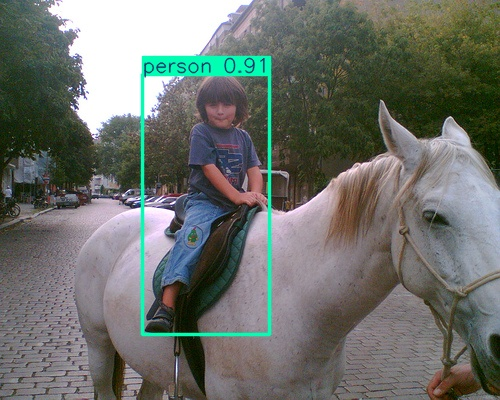

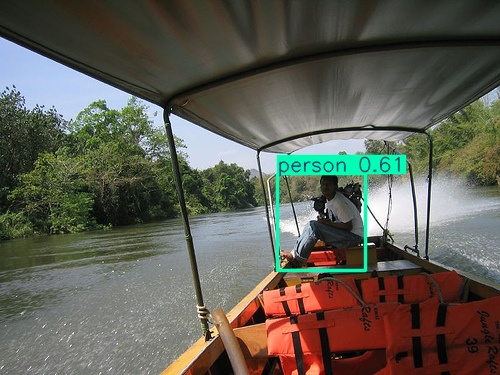

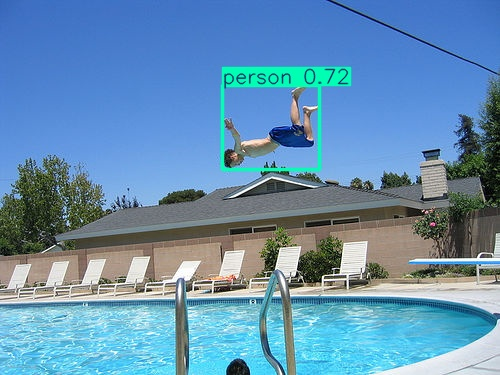

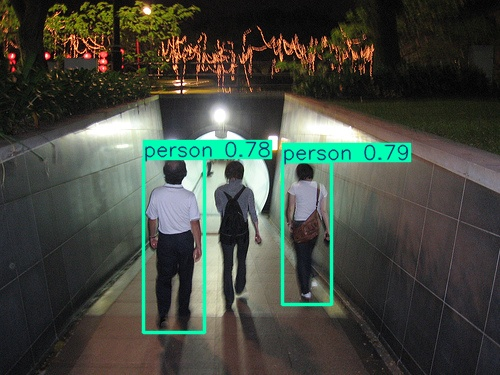

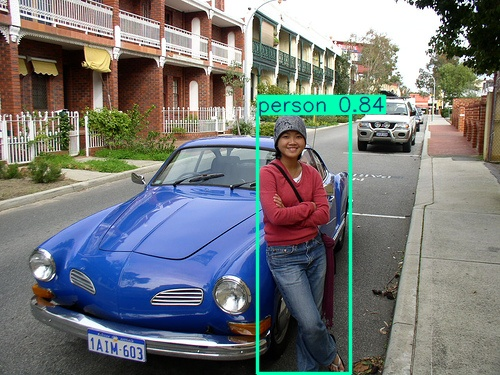

In [27]:
from IPython.display import Image, display
import os

result_dir = "/content/runs/detect/predict"

for img in os.listdir(result_dir):
    display(Image(filename=os.path.join(result_dir, img)))


In [23]:
!ls /content/drive/MyDrive/yolo_dataset


images	labels


In [29]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_VOC_Project/best.pt")

metrics = model.val(data="/content/voc_drive.yaml")

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 3.3±4.5 ms, read: 12.4±20.0 MB/s, size: 86.2 KB)
val: Scanning /content/drive/MyDrive/yolo_dataset/labels/val... 168 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 168/168 2.6it/s 1:06
val: New cache created: /content/drive/MyDrive/yolo_dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.6it/s 4.2s
                   all        168        253      0.264      0.272       0.29      0.218
                 chair          1          2          0          0          0          0
           diningtable          1          1          0          0          0          0
                person        168        250      0.793      0.816      0.871      0.653
Speed: 2.3ms preprocess, 5.5ms inference, 0.0ms loss, 1

Nakon treniranja YOLOv8 modela provedena je evaluacija na validacijskom skupu podataka. Evaluacija omogucuje objektivnu procjenu performansi modela na slikama koje nisu korištene tijekom učenja. Dobiveni rezultati pokazuju precision od 0.79, recall od 0.82 te mAP@0.5 od 0.87, što ukazuje na vrlo dobru sposobnost modela u detekciji objekata klase person. Vrijednost mAP@0.5:0.95 iznosi 0.65, što dodatno potvrduje stabilnost i robusnost modela pri strožim kriterijima evaluacije.

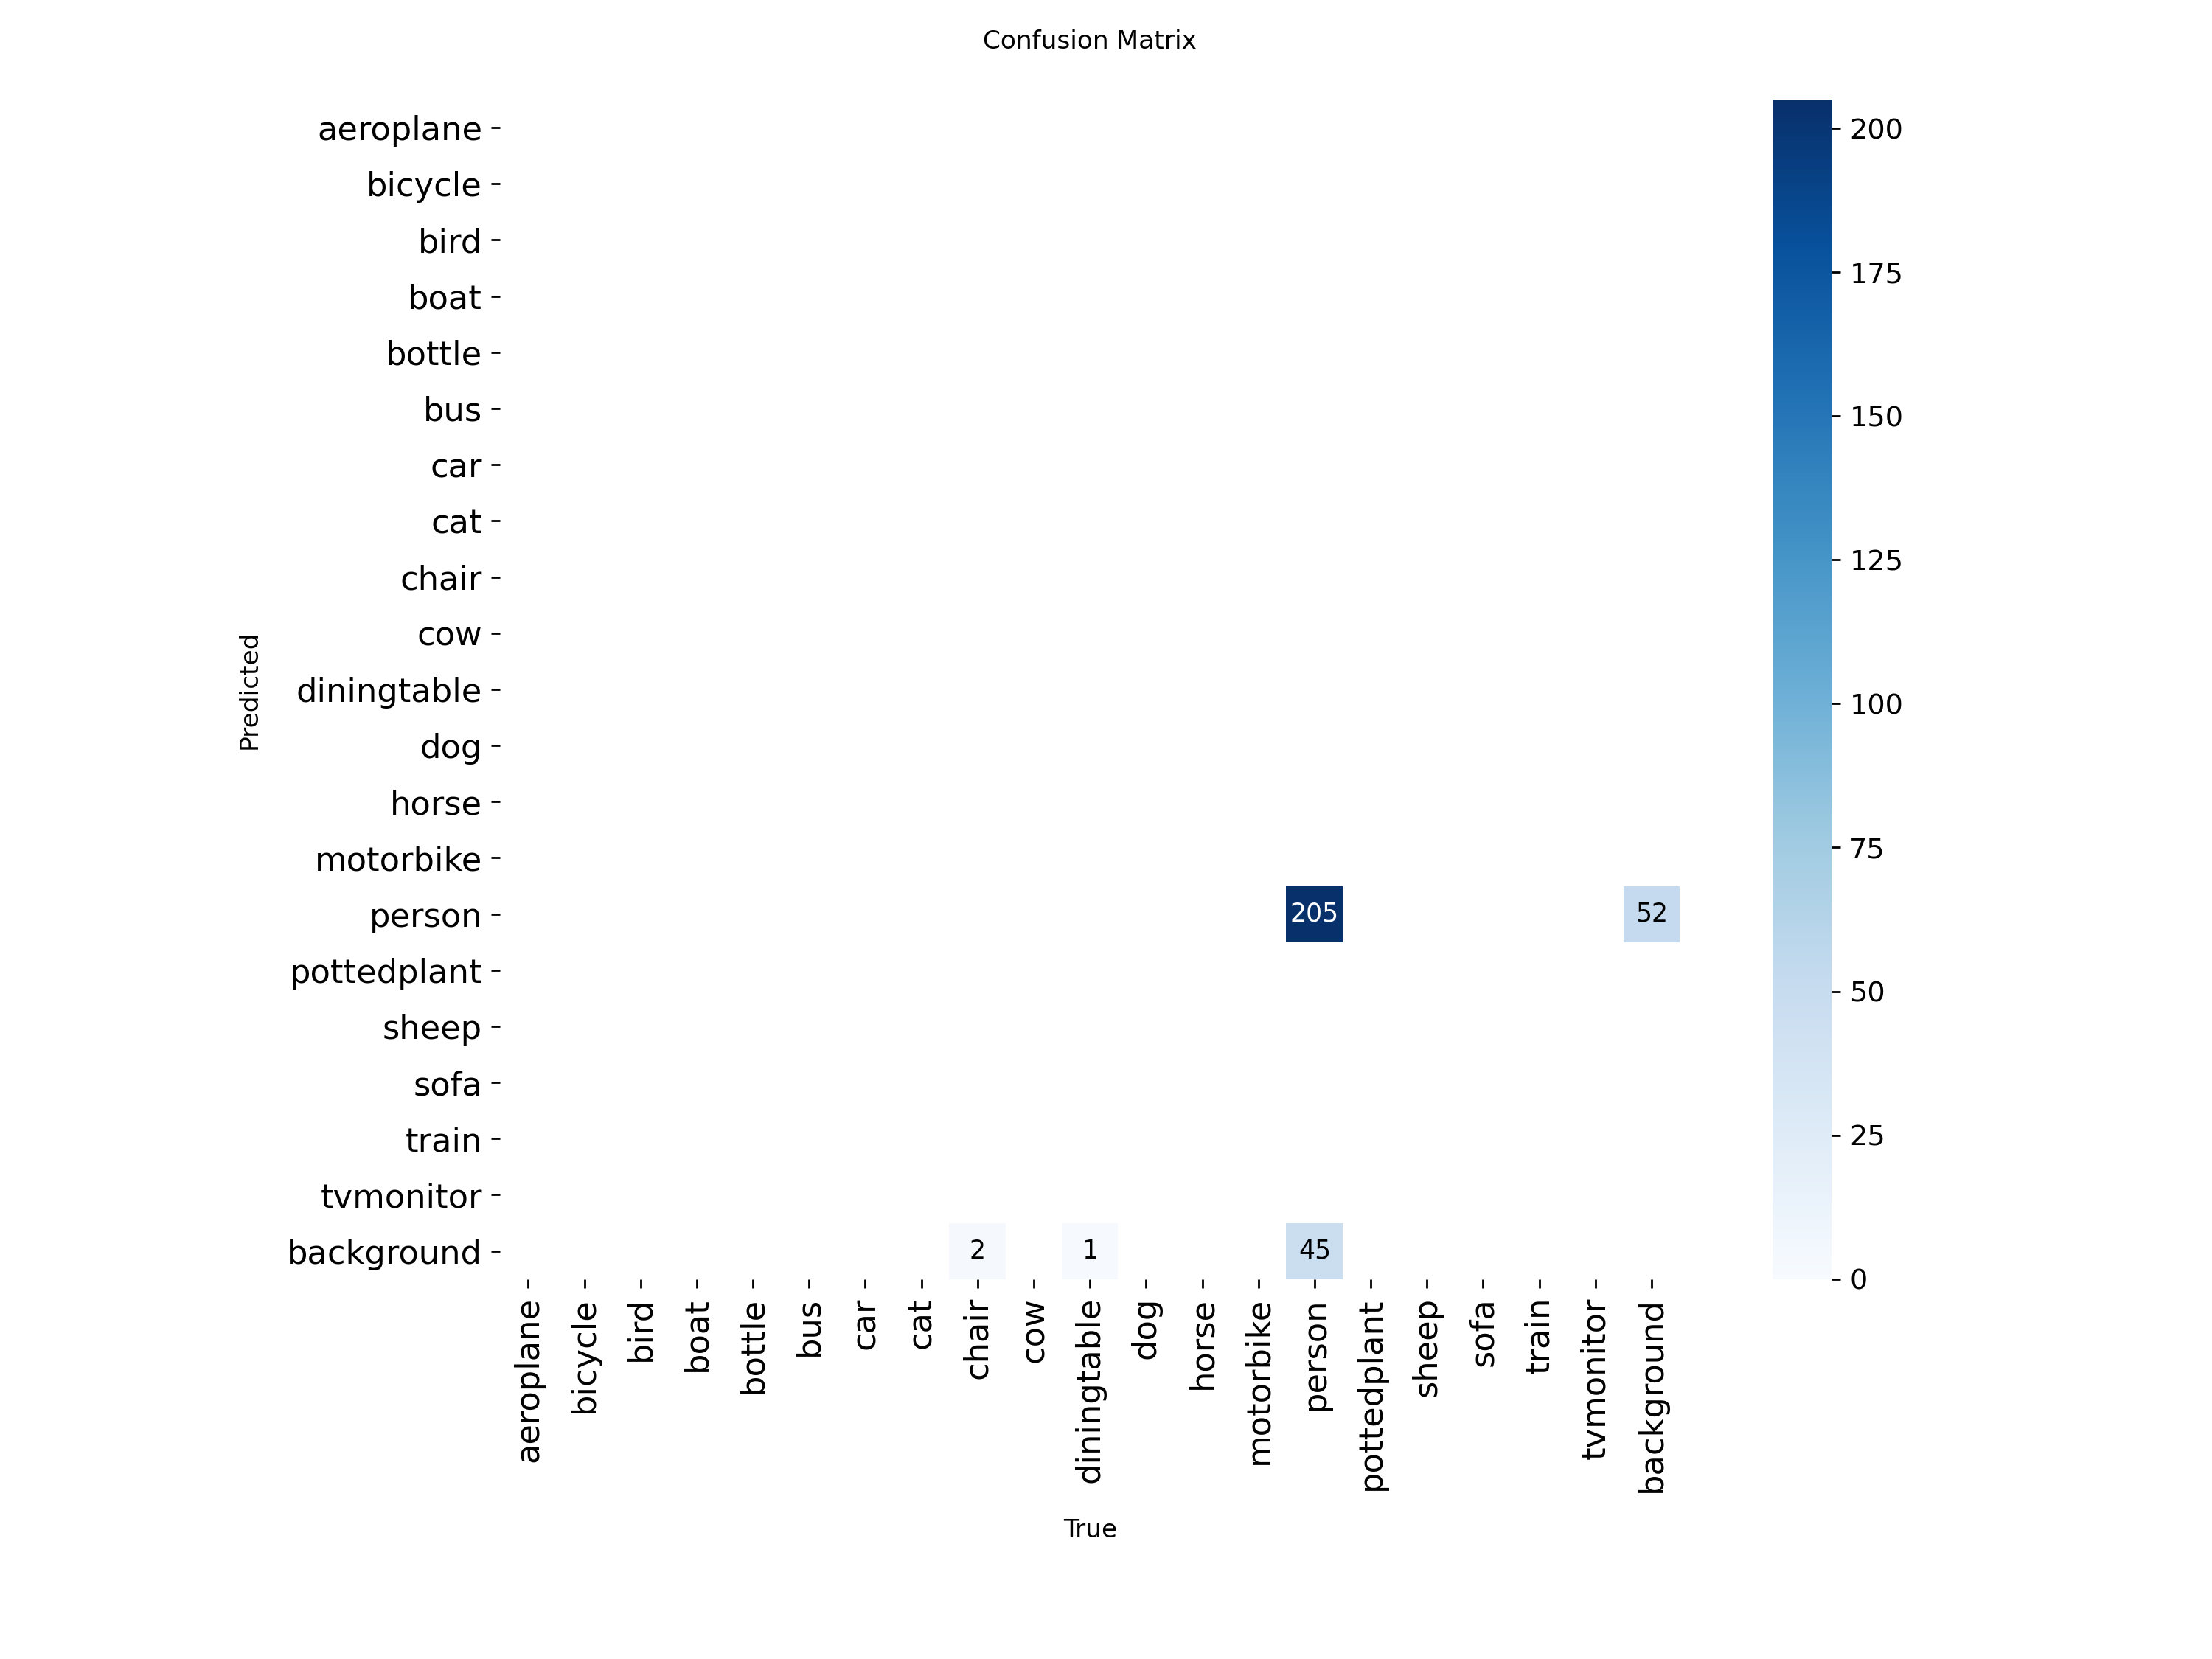

In [30]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/val/confusion_matrix.png"))

In [65]:
from ultralytics import YOLO
from IPython.display import Image, display

model_coco = YOLO("yolov8n.pt")
model_coco.val()

display(Image(filename="/content/runs/detect/val/confusion_matrix.png"))

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco.yaml' images not found, missing path '/content/datasets/coco/val2017.txt'
Unzipping /content/datasets/coco2017labels-segments.zip to /content/datasets/coco...: 100% ━━━━━━━━━━━━ 122232/122232 6.4Kfiles/s 19.2s
Unzipping /content/datasets/coco/images/val2017.zip to /content/datasets/coco/images/val2017...: 100% ━━━━━━━━━━━━ 5001/5001 940.1files/s 5.3s
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 100% ━━━━━━━━━━━━ 40671/40671 369.4files/s 1:50
Unzipping /content/datasets/coco/images/train2017.zip to /content/datasets/coco/images/train2017...: 100% ━━━━━━━━━━━━ 118288/118288 460.1files/s 4:17
Dataset download success ✅ (741.9s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 67.3±17.2 MB/s, size: 179.0 KB)
val: Scanni

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/val/confusion_matrix.png'

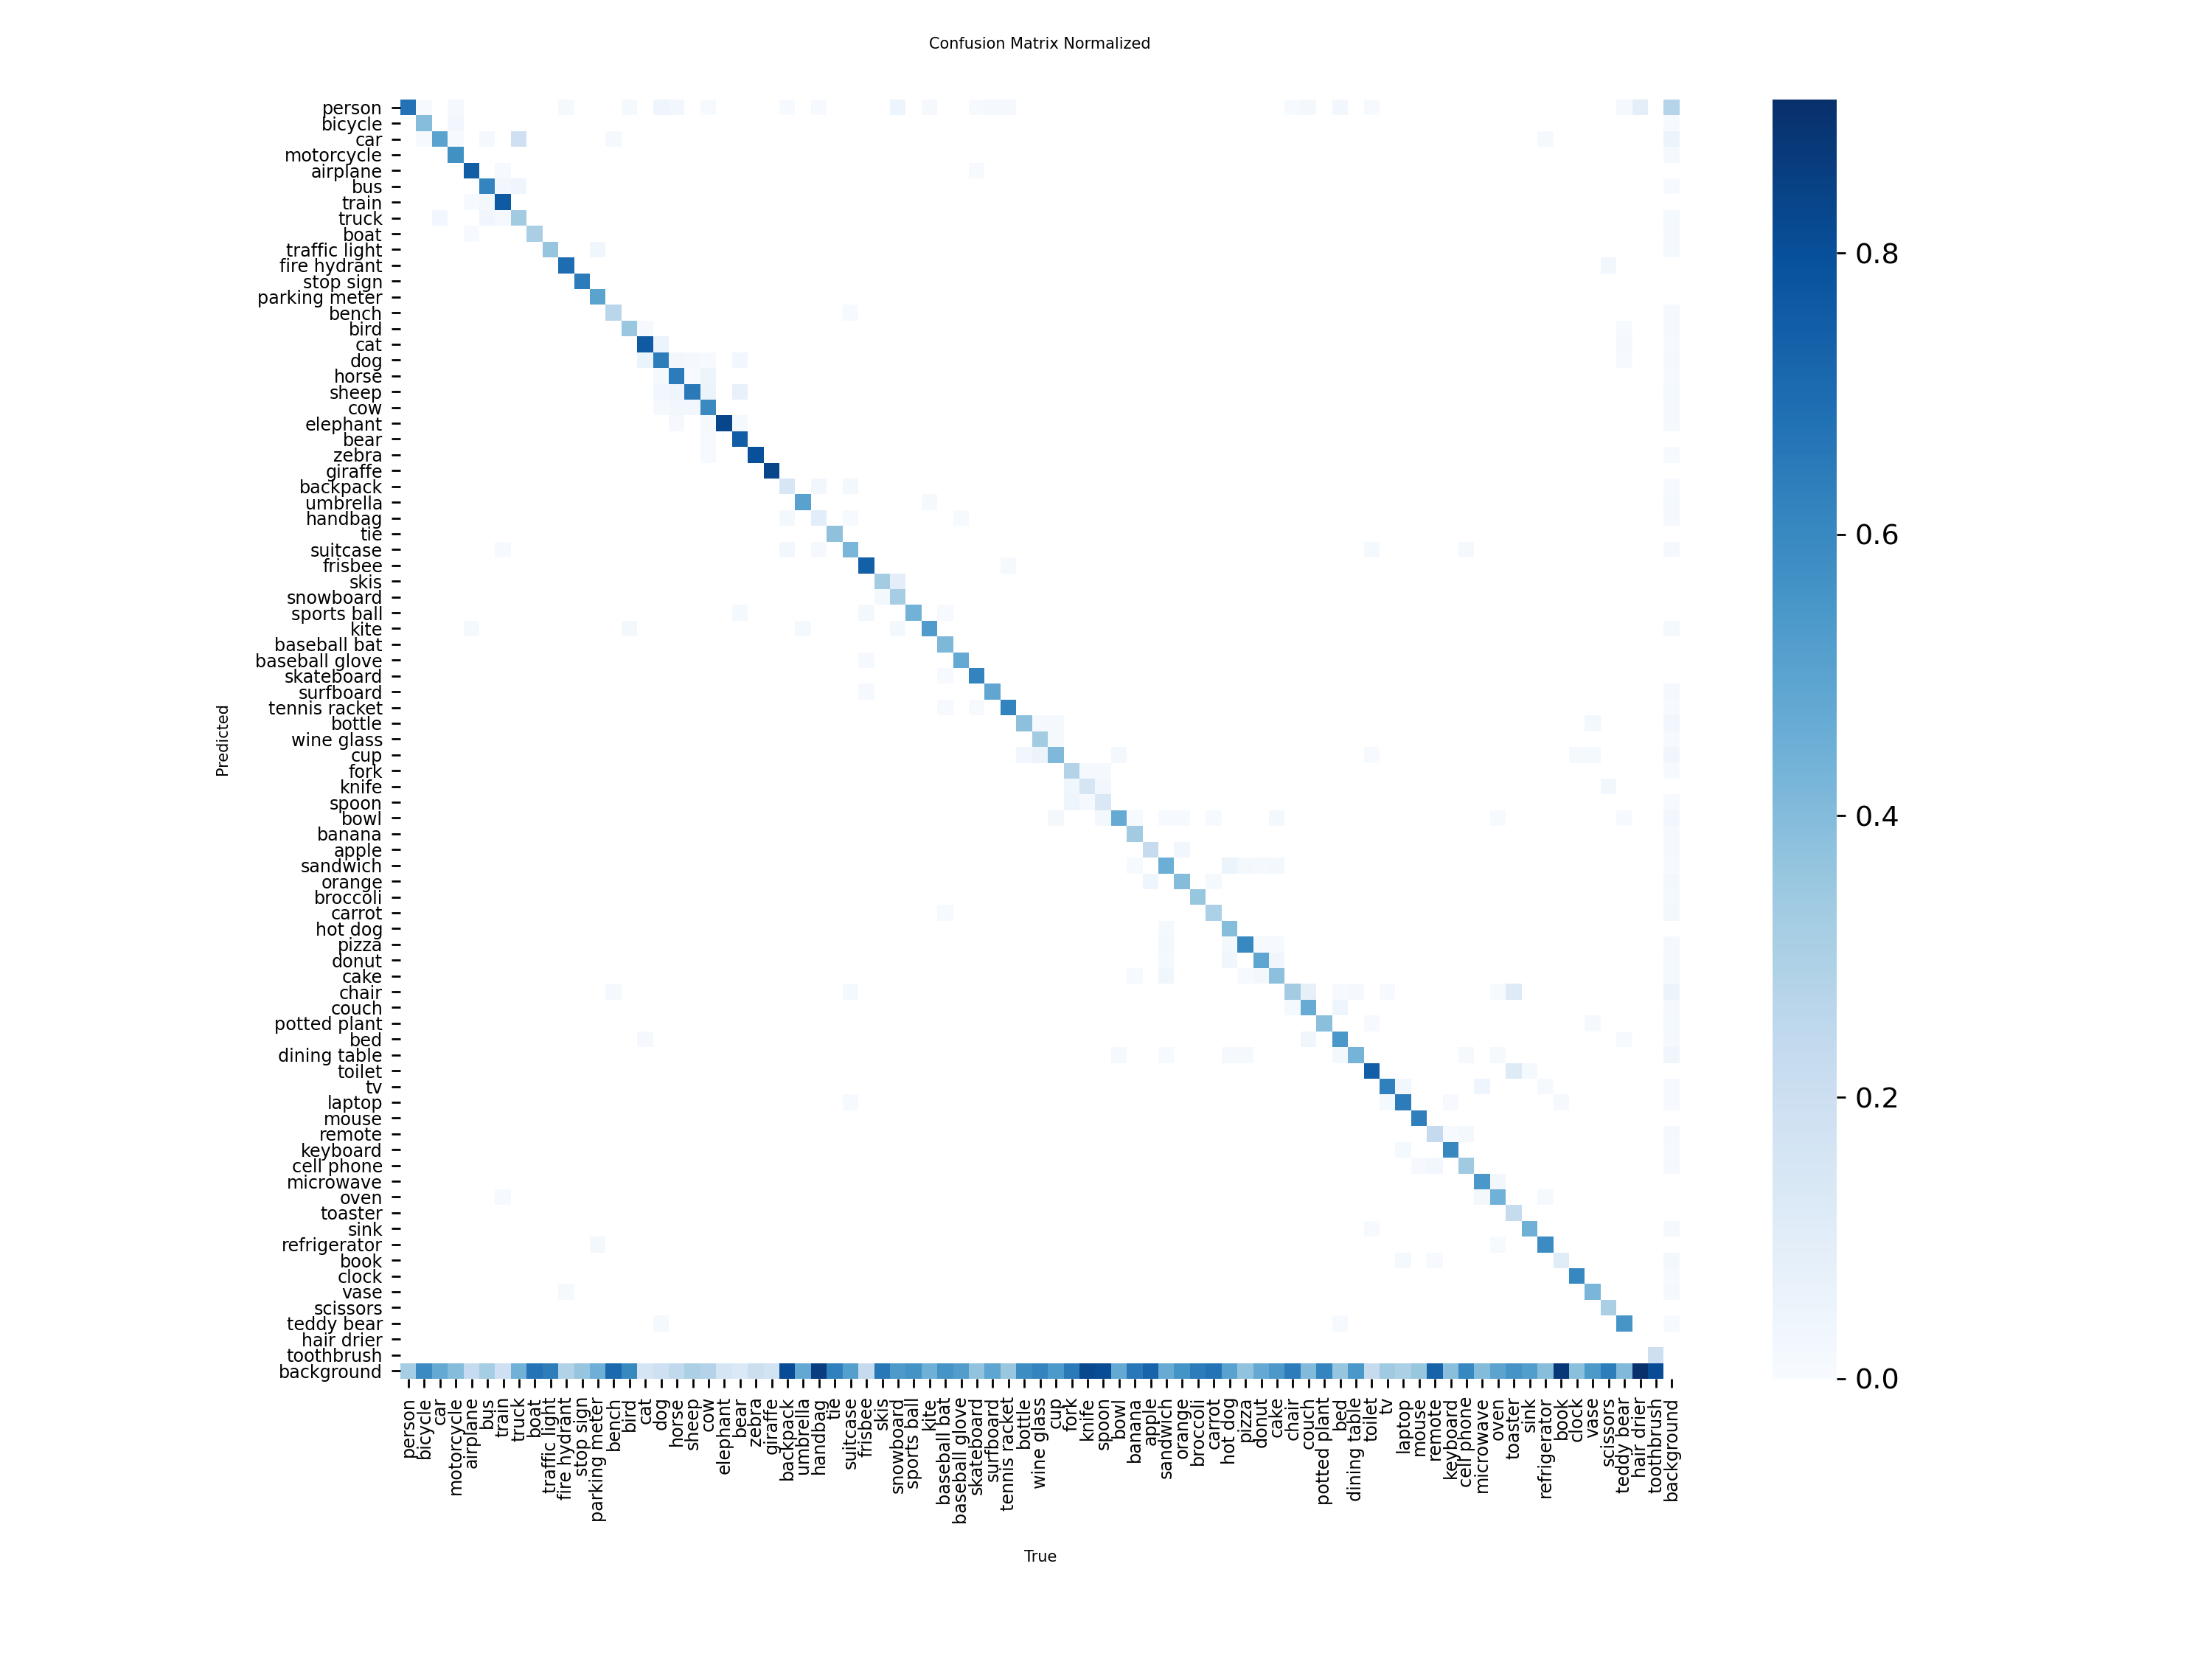

In [70]:
from IPython.display import Image, display
display(Image('/content/runs/detect/val5/confusion_matrix_normalized.png'))



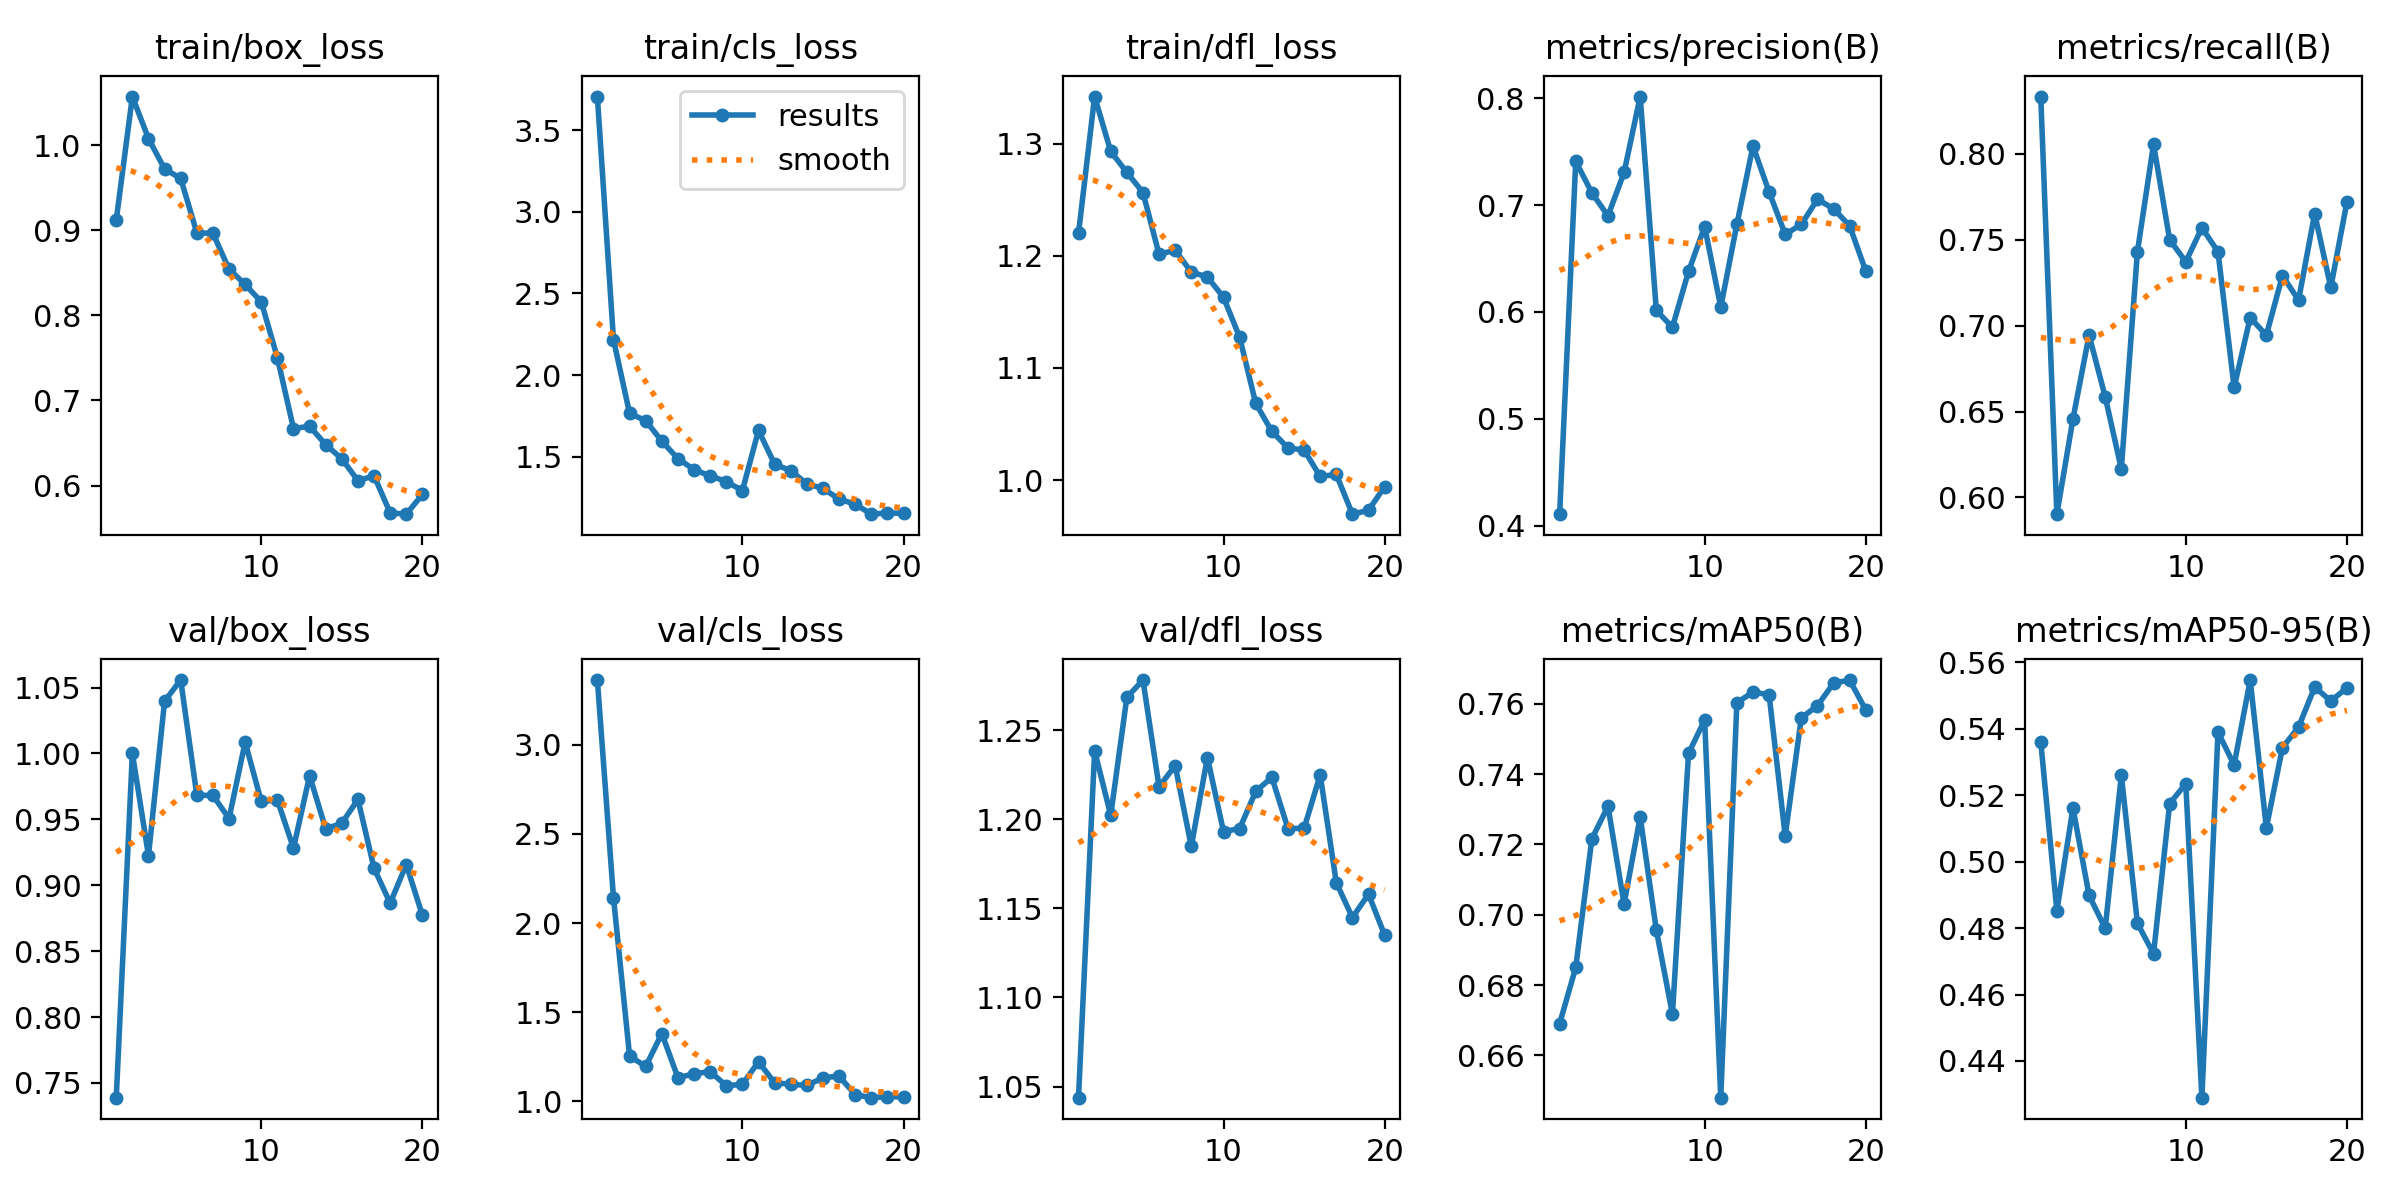

In [34]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/YOLO_VOC_Project/train/results.png"))

Na temelju prikazanih rezultata može se zaključiti da je model uspjesno treniran. Gubici se smanjuju, dok evaluacijske metrike rastu i stabiliziraju se. Model postiže dobre rezultate u detekciji osoba te pokazuje sposobnost generalizacije na neviđene podatke.

In [32]:
!ls /content/drive/MyDrive/YOLO_VOC_Project

best.pt  train


In [33]:
!ls /content/drive/MyDrive/YOLO_VOC_Project/train

args.yaml			 results.csv	     val_batch0_labels.jpg
BoxF1_curve.png			 results.png	     val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg    val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg    val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg    val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch300.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch301.jpg  weights
labels.jpg			 train_batch302.jpg


In [35]:
precision = 0.70
recall = 0.75

f1 = 2 * (precision * recall) / (precision + recall)
print("F1-score:", f1)

F1-score: 0.7241379310344827


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 210MB/s]


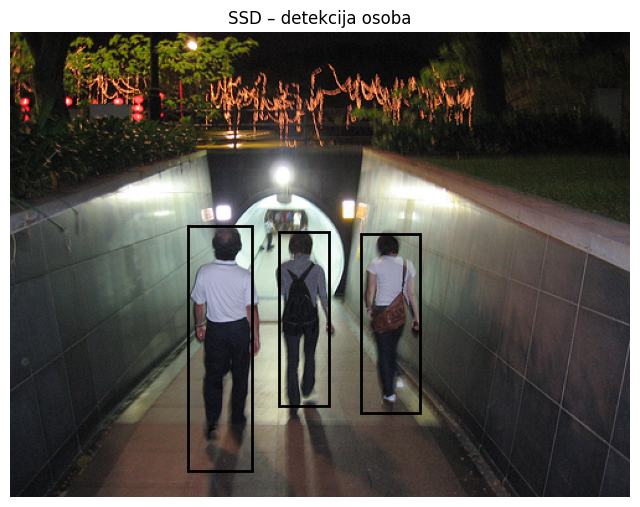

In [36]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# učitaj pretrenirani SSD model
model = torchvision.models.detection.ssd300_vgg16(pretrained=True)
model.eval()

# transformacija slike
transform = transforms.Compose([
    transforms.ToTensor()
])

# putanja do tvoje slike
img_path = "/content/drive/MyDrive/VOC_test_imagees/test3.jpg"

image = Image.open(img_path).convert("RGB")
img_tensor = transform(image).unsqueeze(0)

# predikcija
with torch.no_grad():
    outputs = model(img_tensor)

# prikaži rezultate
boxes = outputs[0]['boxes']
scores = outputs[0]['scores']
labels = outputs[0]['labels']

plt.figure(figsize=(8,8))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    if score > 0.5 and label == 1:  # label 1 = person u COCO
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax.add_patch(rect)

plt.title("SSD – detekcija osoba")
plt.axis("off")
plt.show()

SSD model pokazuje nešto bolju generalizaciju na nekim složenim scenama, što je očekivano jer je treniran na znatno većem COCO skupu podataka. Međutim, YOLOv8 treniran na VOC skupu postiže vrlo dobre rezultate uz znatno manji broj epoha i manju količinu podataka, što potvrđuje njegovu učinkovitost i brzinu učenja.